In [3]:
import warnings
warnings.simplefilter("ignore")

In [4]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT/"dataset"

annotations = pd.read_csv(DATA_DIR/"magnatagatune"/"annotations_final.csv", sep="\t")
clip_info = pd.read_csv(DATA_DIR/"magnatagatune"/"clip_info_final.csv", sep="\t")

print("annotations shape:", annotations.shape)
print("clip info shape:", clip_info.shape)

annotations shape: (25863, 190)
clip info shape: (31382, 10)


In [5]:
annotations.columns.tolist()

['clip_id',
 'no voice',
 'singer',
 'duet',
 'plucking',
 'hard rock',
 'world',
 'bongos',
 'harpsichord',
 'female singing',
 'clasical',
 'sitar',
 'chorus',
 'female opera',
 'male vocal',
 'vocals',
 'clarinet',
 'heavy',
 'silence',
 'beats',
 'men',
 'woodwind',
 'funky',
 'no strings',
 'chimes',
 'foreign',
 'no piano',
 'horns',
 'classical',
 'female',
 'no voices',
 'soft rock',
 'eerie',
 'spacey',
 'jazz',
 'guitar',
 'quiet',
 'no beat',
 'banjo',
 'electric',
 'solo',
 'violins',
 'folk',
 'female voice',
 'wind',
 'happy',
 'ambient',
 'new age',
 'synth',
 'funk',
 'no singing',
 'middle eastern',
 'trumpet',
 'percussion',
 'drum',
 'airy',
 'voice',
 'repetitive',
 'birds',
 'space',
 'strings',
 'bass',
 'harpsicord',
 'medieval',
 'male voice',
 'girl',
 'keyboard',
 'acoustic',
 'loud',
 'classic',
 'string',
 'drums',
 'electronic',
 'not classical',
 'chanting',
 'no violin',
 'not rock',
 'no guitar',
 'organ',
 'no vocal',
 'talking',
 'choral',
 'weird',
 '

In [6]:
tag_counts = annotations.iloc[:, 1:-1].sum().sort_values(ascending=False)

tag_counts.head(50)

guitar          4852
classical       4272
slow            3547
techno          2954
strings         2729
drums           2598
electronic      2519
rock            2371
fast            2306
piano           2056
ambient         1956
beat            1906
violin          1826
vocal           1729
synth           1717
female          1474
indian          1395
opera           1296
male            1279
singing         1211
vocals          1184
no vocals       1158
harpsichord     1093
loud            1086
quiet           1055
flute           1025
woman           1016
male vocal      1002
no vocal         995
pop              995
soft             985
sitar            926
solo             826
man              741
classic          691
choir            688
voice            665
new age          650
dance            649
female vocal     644
male voice       644
beats            634
harp             623
cello            575
no voice         573
weird            557
country          541
metal        

In [7]:
top_50_tags = tag_counts.head(50).index
task1_data = annotations[['clip_id'] + list(top_50_tags)]

task1_data.shape

(25863, 51)

In [8]:
text_data = clip_info[['clip_id', 'title', 'artist', 'album']]

text_data.head()

,clip_id,title,artist,album
0,2,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
1,6,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
2,10,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
3,11,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas
4,12,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas


In [9]:
text_data = clip_info[['clip_id', 'title', 'artist', 'album']]

text_data.tail()

,clip_id,title,artist,album
31377,58899,La Bressanina,Jacob Heringman,Blame Not My Lute
31378,58906,Lost is my Lyberty,Jacob Heringman,Blame Not My Lute
31379,58907,Lost is my Lyberty,Jacob Heringman,Blame Not My Lute
31380,58908,Lost is my Lyberty,Jacob Heringman,Blame Not My Lute
31381,58915,A Toy for Monica Bishop,Jacob Heringman,Blame Not My Lute


In [10]:
text_data = clip_info[['clip_id', 'title', 'artist', 'album']].copy()

text_data["text"] = (text_data["title"] + " by " + text_data["artist"] + " from " + text_data["album"])

text_data[["clip_id", "text"]].head()

,clip_id,text
0,2,BWV54 - I Aria by American Bach Soloists from ...
1,6,BWV54 - I Aria by American Bach Soloists from ...
2,10,BWV54 - I Aria by American Bach Soloists from ...
3,11,BWV54 - I Aria by American Bach Soloists from ...
4,12,BWV54 - I Aria by American Bach Soloists from ...


In [11]:
text_data[["clip_id", "text"]].tail()

,clip_id,text
31377,58899,La Bressanina by Jacob Heringman from Blame No...
31378,58906,Lost is my Lyberty by Jacob Heringman from Bla...
31379,58907,Lost is my Lyberty by Jacob Heringman from Bla...
31380,58908,Lost is my Lyberty by Jacob Heringman from Bla...
31381,58915,A Toy for Monica Bishop by Jacob Heringman fro...


In [12]:
task1_data = text_data.merge(task1_data, on="clip_id")

task1_data.shape

(25863, 55)

In [13]:
task1_data.head()

,clip_id,title,artist,album,text,guitar,classical,slow,techno,strings,...,male voice,beats,harp,cello,no voice,weird,country,metal,female voice,choral
0,2,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,6,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,10,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,11,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12,BWV54 - I Aria,American Bach Soloists,J.S. Bach Solo Cantatas,BWV54 - I Aria by American Bach Soloists from ...,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [14]:
task1_data[['title', 'artist', 'album', 'text']].isnull().sum()

title     0
artist    0
album     0
text      0
dtype: int64

In [15]:
task1_data.to_csv(DATA_DIR/"processed"/"task1_data.csv", index=False)

f'Task 1 dataset saved to Processed Folder'

'Task 1 dataset saved to Processed Folder'

In [16]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(task1_data, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42)

print("train:", len(train_data))
print("validation:", len(val_data))
print("test:", len(test_data))

train: 16552
validation: 4138
test: 5173


In [17]:
X_train = train_data["text"]
y_train = train_data[top_50_tags]

X_val = val_data["text"]
y_val = val_data[top_50_tags]

X_test = test_data["text"]
y_test = test_data[top_50_tags]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (16552,)
y_train shape: (16552, 50)


In [18]:
# import torch

# print(torch.__version__)
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))

In [19]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [20]:
train_tokens = tokenizer(X_train.tolist(), padding=True, truncation=True, max_length=128)
val_tokens = tokenizer(X_val.tolist(), padding=True, truncation=True, max_length=128)
test_tokens = tokenizer(X_test.tolist(), padding=True, truncation=True, max_length=128)

train_tokens.keys();

In [21]:
import torch

train_dataset = torch.utils.data.TensorDataset(torch.tensor(train_tokens["input_ids"]), torch.tensor(y_train.values))
val_dataset = torch.utils.data.TensorDataset(torch.tensor(val_tokens["input_ids"]), torch.tensor(y_val.values))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(test_tokens["input_ids"]), torch.tensor(y_test.values))

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 16552
Validation dataset size: 4138
Test dataset size: 5173


In [22]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print("Train loader size:", len(train_loader))
print("Validation loader size:", len(val_loader))
print("Test loader size:", len(test_loader))

Train loader size: 1035
Validation loader size: 259
Test loader size: 324


In [23]:
for i, batch in enumerate(train_loader):
    print("Train batch", i, "input shape:", batch[0].shape)
    print("Train batch", i, "target shape:", batch[1].shape)
    break

Train batch 0 input shape: torch.Size([16, 59])
Train batch 0 target shape: torch.Size([16, 50])


In [24]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=50, problem_type="multi_label_classification")
optimizer = AdamW(model.parameters(), lr=2e-5)

optimizer

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5276.92it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 2e-05
    maximize: False
    weight_decay: 0.01
)

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [26]:
import numpy as np
import torch.nn as nn
from sklearn.metrics import f1_score, average_precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

loss_fn = nn.BCEWithLogitsLoss()

epochs = 100
patience = 10
best_micro_f1 = 0.0
wait = 0

train_losses = []
val_losses = []
accuracies = []
macro_f1s = []
micro_f1s = []
auc_prs = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch[0].to(device)
        labels = batch[1].float().to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"epoch: {epoch + 1} batch: {batch_idx} loss: {loss.item():.6f}")

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            input_ids = batch[0].to(device)
            labels = batch[1].float().to(device)

            outputs = model(input_ids=input_ids)
            loss = loss_fn(outputs.logits, labels)

            val_loss += loss.item()

            probabilities = torch.sigmoid(outputs.logits)

            all_probabilities.append(probabilities.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    val_loss /= len(val_loader)

    all_probabilities = np.concatenate(all_probabilities, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    predictions = (all_probabilities >= 0.1).astype(int)

    accuracy = np.mean(all_labels == predictions)

    micro_f1 = f1_score(all_labels, predictions, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, predictions, average="macro", zero_division=0)
    auc_pr = average_precision_score(all_labels, all_probabilities, average="macro")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    accuracies.append(accuracy)
    macro_f1s.append(macro_f1)
    micro_f1s.append(micro_f1)
    auc_prs.append(auc_pr)

    print(f"epoch: {epoch + 1} train loss: {train_loss:.6f} validation loss: {val_loss:.6f}")

    print(f"accuracy: {accuracy:.6f} macro-f1: {macro_f1:.6f} micro-f1: {micro_f1:.6f} AUC-PR: {auc_pr:.6f}")

    if micro_f1 > best_micro_f1:
        best_micro_f1 = micro_f1
        wait = 0
        torch.save(model.state_dict(), "saved_models/t1_bert_best_model.pt")
        print("best model saved")

    else:
        wait += 1
        print(f"no improvement: {wait}")

    if wait >= patience:
        print("early stopping")
        break

epoch: 1 batch: 0 loss: 0.708171
epoch: 1 batch: 100 loss: 0.265634
epoch: 1 batch: 200 loss: 0.172148
epoch: 1 batch: 300 loss: 0.243829
epoch: 1 batch: 400 loss: 0.194848
epoch: 1 batch: 500 loss: 0.202044
epoch: 1 batch: 600 loss: 0.162495
epoch: 1 batch: 700 loss: 0.182045
epoch: 1 batch: 800 loss: 0.154057
epoch: 1 batch: 900 loss: 0.151087
epoch: 1 batch: 1000 loss: 0.212963
epoch: 1 train loss: 0.212642 validation loss: 0.178906
accuracy: 0.865529 macro-f1: 0.154567 micro-f1: 0.291520 AUC-PR: 0.186896
best model saved
epoch: 2 batch: 0 loss: 0.162450
epoch: 2 batch: 100 loss: 0.158263
epoch: 2 batch: 200 loss: 0.150908
epoch: 2 batch: 300 loss: 0.163545
epoch: 2 batch: 400 loss: 0.151418
epoch: 2 batch: 500 loss: 0.166878
epoch: 2 batch: 600 loss: 0.145201
epoch: 2 batch: 700 loss: 0.162967
epoch: 2 batch: 800 loss: 0.191529
epoch: 2 batch: 900 loss: 0.158678
epoch: 2 batch: 1000 loss: 0.156261
epoch: 2 train loss: 0.163001 validation loss: 0.154738
accuracy: 0.864857 macro-f1: 

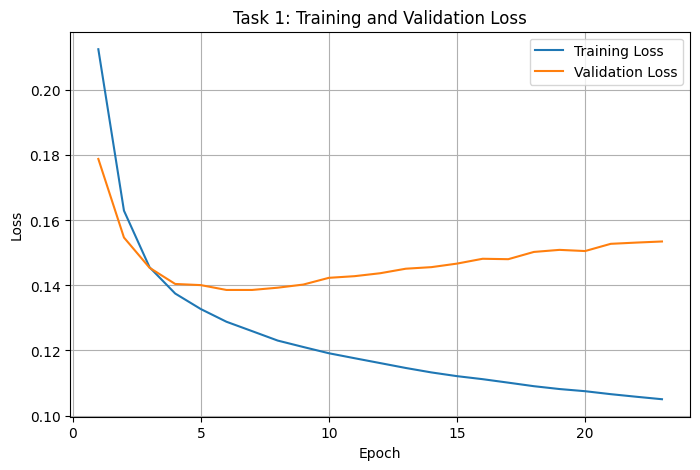

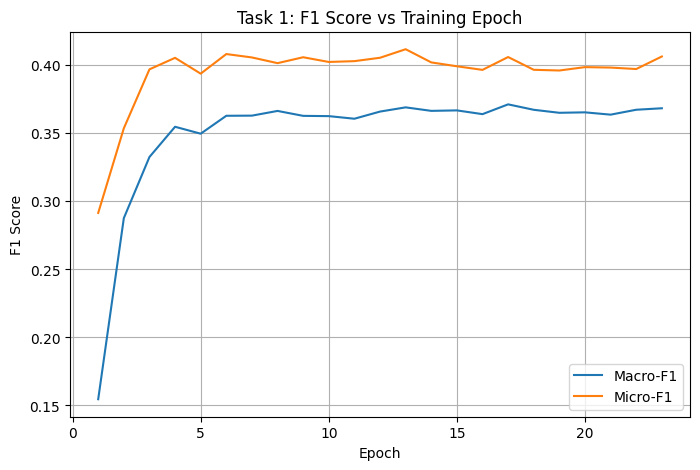

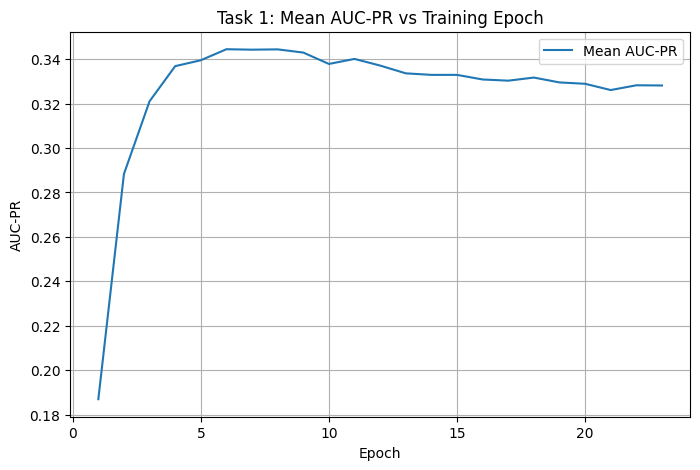

In [27]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("saved_models/t1_bert_best_model.pt", map_location=device))
model.eval()

epochs_completed = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, train_losses, label="Training Loss")
plt.plot(epochs_completed, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 1: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("../results/task1/t1_bert_loss_plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, macro_f1s, label="Macro-F1")
plt.plot(epochs_completed, micro_f1s, label="Micro-F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Task 1: F1 Score vs Training Epoch")
plt.legend()
plt.grid(True)
plt.savefig("../results/task1/t1_bert_f1_plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, auc_prs, label="Mean AUC-PR")
plt.xlabel("Epoch")
plt.ylabel("AUC-PR")
plt.title("Task 1: Mean AUC-PR vs Training Epoch")
plt.legend()
plt.grid(True)
plt.savefig("../results/task1/t1_bert_auc_pr_plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [28]:
from sklearn.metrics import (
    f1_score,
    average_precision_score
)

model.load_state_dict(torch.load("saved_models/t1_bert_best_model.pt", map_location=device))
model.eval()

test_probabilities = []
test_labels = []

with torch.no_grad():

    for batch in test_loader:
        input_ids = batch[0].to(device)
        labels = batch[1].float().to(device)

        outputs = model(input_ids=input_ids)

        probabilities = torch.sigmoid(outputs.logits)

        test_probabilities.append(probabilities.cpu().numpy())
        test_labels.append(labels.cpu().numpy())

test_probabilities = np.concatenate(test_probabilities, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

test_predictions = (test_probabilities >= 0.1).astype(int)

test_accuracy = np.mean(test_labels == test_predictions)

test_micro_f1 = f1_score(test_labels, test_predictions, average="micro", zero_division=0)
test_macro_f1 = f1_score(test_labels, test_predictions, average="macro", zero_division=0)
test_auc_pr = average_precision_score(test_labels, test_probabilities, average="macro")

print("===== Task 1 Test Results =====")
print(f"Accuracy (element-wise): {test_accuracy:.4f}")
print(f"Macro-F1:                {test_macro_f1:.4f}")
print(f"Micro-F1:                {test_micro_f1:.4f}")
print(f"Mean AUC-PR:             {test_auc_pr:.4f}")

===== Task 1 Test Results =====
Accuracy (element-wise): 0.8952
Macro-F1:                0.3646
Micro-F1:                0.4093
Mean AUC-PR:             0.3315


In [29]:
tag_names = list(task1_data.columns[5:55])

for i in range(5):
    actual_tags = []
    predicted_tags = []

    for j, tag in enumerate(tag_names):
        if all_labels[i][j] == 1:
            actual_tags.append(tag)

        if predictions[i][j] == 1:
            predicted_tags.append(tag)

    print("Example", i + 1, ":")
    print("Text:", test_data.iloc[i]["text"])
    print("Actual tags:", actual_tags)
    print("Predicted tags:", predicted_tags)
    print()

Example 1 :
Text: Part 2 by Four Stones.Net from Ridin the Faders
Actual tags: []
Predicted tags: ['techno', 'rock', 'fast', 'beat', 'female', 'vocals', 'loud', 'pop']

Example 2 :
Text: Suite VI in Re magiore - sarabande by Vito Paternoster from CD1-Bach Cello Suites
Actual tags: ['techno', 'drums', 'rock']
Predicted tags: ['female', 'woman', 'female voice']

Example 3 :
Text: Wet Brain by Pizzle from Party Patrol
Actual tags: ['rock', 'metal']
Predicted tags: ['guitar', 'drums', 'rock', 'fast', 'loud', 'metal']

Example 4 :
Text: Lighting fly by Strojovna 07 from Mirnix
Actual tags: ['classical', 'strings', 'ambient', 'pop']
Predicted tags: ['slow', 'electronic', 'ambient', 'synth', 'no vocals', 'no vocal', 'new age']

Example 5 :
Text: smithee's second by Drop Trio from Cezanne
Actual tags: ['techno', 'electronic', 'synth', 'dance', 'beats']
Predicted tags: ['techno', 'electronic', 'beat', 'synth', 'no vocal']

